# **Motivation**

Exploratory Data Analysis (EDA) serves as the foundation of the entire ML pipeline: it exposes the structure, quality, and limitations of the datasets before any modelling decision is made.

In the context of drug discovery, the data used to train binding affinity models — here represented by two datasets, pChEMBL and pKi — is inherently complex. Each data point integrates information from multiple sources: structural data from the PDB, chemical descriptors of the ligand, and protein sequence embeddings from a large language model (ESM2). Understanding how these different feature spaces are distributed, how complete they are, and how they relate to the target variable is critical for making informed choices about preprocessing, feature selection, and model design.

## **Set Up**

In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

#Load data
os.chdir("/Users/leonorafonso/Documents/Work/ML/protein_ligand_binding_affinity_pipeline")
df_pchembl = pd.read_csv("data/processed/features_processed_pchembl.csv") 
df_pki = pd.read_csv("data/processed/features_processed_pki.csv")

### **pchembl**

In [2]:
print(f"Shape pchembl: {df_pchembl.shape}")
df_pchembl.head()

Shape pchembl: (14215, 1511)


,PDB ID,Chain ID,UniProt_ID,PDB_Start,PDB_End,UniProt_Start,UniProt_End,LIGAND_ID,LIGAND_TYPE,POSITIONS,...,ESM2_1271,ESM2_1272,ESM2_1273,ESM2_1274,ESM2_1275,ESM2_1276,ESM2_1277,ESM2_1278,ESM2_1279,ESM2_1280
0,3hng,A,P17948,801.0,1158.0,801.0,1158.0,8ST,non-polymer,803-804-805-806-807-808-809-810-811-812-814-81...,...,-0.015735,-0.069448,-0.122089,0.089782,0.079008,0.024245,0.022678,-0.155095,0.084603,0.102680
1,3rze,A,P35367,20.0,221.0,20.0,221.0,D7V,non-polymer,28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-4...,...,-0.016722,-0.050202,-0.131262,0.090381,-0.002870,0.103428,-0.008312,-0.148286,-0.054626,0.182683
2,3s3g,A,P15121,0.0,315.0,1.0,316.0,TLT,non-polymer,0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18...,...,-0.015408,0.025305,-0.069743,-0.020872,-0.027593,-0.026930,0.108785,-0.167165,0.067902,0.021568
3,4bb2,A,P08185,11.0,349.0,33.0,371.0,STR,non-polymer,13-14-15-16-17-18-19-20-21-22-23-24-25-26-27-2...,...,0.006046,0.026167,-0.153604,-0.016363,-0.071788,-0.029067,0.036498,-0.043937,-0.079267,-0.111932
4,4bb2,B,P08185,350.0,383.0,372.0,405.0,STR,non-polymer,351-352-353-354-355-356-357-358-359-360-361-36...,...,0.066247,0.058355,-0.145837,0.200997,0.009985,-0.002678,0.114186,-0.021531,-0.067303,-0.111025


### **pki**

In [3]:
print(f"Shape pki: {df_pki.shape}")
df_pki.head()

Shape pki: (3744, 1508)


,PDB ID,Chain ID,UniProt_ID,PDB_Start,PDB_End,UniProt_Start,UniProt_End,LIGAND_ID,LIGAND_TYPE,POSITIONS,...,ESM2_1271,ESM2_1272,ESM2_1273,ESM2_1274,ESM2_1275,ESM2_1276,ESM2_1277,ESM2_1278,ESM2_1279,ESM2_1280
0,3vn2,A,P37231,197.0,477.0,225.0,505.0,TLS,non-polymer,207-208-209-210-211-212-213-214-215-216-217-21...,...,0.167744,-0.020716,-0.071077,-0.001349,0.019589,0.048223,0.051993,-0.132710,0.003625,0.096680
1,3rze,A,P35367,20.0,221.0,20.0,221.0,D7V,non-polymer,28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-4...,...,-0.016722,-0.050202,-0.131262,0.090381,-0.002870,0.103428,-0.008312,-0.148286,-0.054626,0.182683
2,1ogu,C,P24941,1.0,298.0,1.0,298.0,ST8,non-polymer,-2--1-0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16...,...,0.049288,-0.029072,-0.088495,0.076983,0.012994,0.020578,0.029090,-0.154393,0.066327,0.069026
3,1ogu,A,P24941,1.0,298.0,1.0,298.0,ST8,non-polymer,-2--1-0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16...,...,0.018536,-0.004901,-0.090479,0.069037,0.034864,0.012300,0.047755,-0.135179,0.091673,0.027348
4,2pd5,A,P15121,0.0,315.0,1.0,316.0,ZST,non-polymer,1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-1...,...,-0.014680,0.023218,-0.067833,-0.022322,-0.028317,-0.029800,0.108567,-0.170323,0.069251,0.025469


## **Data Overview**

### **pchembl**

In [4]:
def overview(df_pchembl):
    display(df_pchembl.info())
    display(df_pchembl.describe().T)

overview(df_pchembl)

# Column groups
id_cols = ['PDB ID', 'Chain ID', 'UniProt_ID']
target_cols = ['pchembl_value', 'standard_value']
chem_cols = [c for c in df_pchembl.columns if 'Mol' in c or 'TPSA' in c or 'LogP' in c]
esm_cols = [c for c in df_pchembl.columns if c.startswith('ESM2_')]

print(f"Chem features pchembl: {len(chem_cols)}")
print(f"ESM features pchembl: {len(esm_cols)}")

<class 'pandas.DataFrame'>
RangeIndex: 14215 entries, 0 to 14214
Columns: 1511 entries, PDB ID to ESM2_1280
dtypes: float64(1486), str(25)
memory usage: 163.9 MB


None

,count,mean,std,min,25%,50%,75%,max
PDB_Start,13842.0,214.821269,341.051104,0.000000,1.000000,45.000000,302.000000,3813.000000
PDB_End,14193.0,534.763757,374.907596,6.000000,298.000000,441.000000,678.000000,4128.000000
UniProt_Start,14215.0,217.983539,334.078503,0.000000,2.000000,64.000000,302.000000,3813.000000
UniProt_End,14215.0,542.776926,367.764504,6.000000,312.000000,454.000000,693.000000,4128.000000
Resolution,14187.0,2.211027,0.531097,0.660000,1.850000,2.150000,2.546000,7.800000
...,...,...,...,...,...,...,...,...
ESM2_1276,14215.0,-0.016697,0.063294,-0.290043,-0.052484,-0.021202,0.018842,0.188805
ESM2_1277,14215.0,0.050897,0.053389,-0.143499,0.014298,0.047779,0.086431,0.241708
ESM2_1278,14215.0,-0.156329,0.071413,-0.415671,-0.201889,-0.148686,-0.110828,0.083224
ESM2_1279,14215.0,0.008226,0.061058,-0.211114,-0.029089,0.004466,0.050110,0.202755


Chem features pchembl: 6
ESM features pchembl: 1280


### **pki**

In [5]:
def overview(df_pki):
    display(df_pki.info())
    display(df_pki.describe().T)

overview(df_pki)

# Column groups
id_cols = ['PDB ID', 'Chain ID', 'UniProt_ID']
target_cols = ['pchembl_value', 'standard_value']
chem_cols = [c for c in df_pki.columns if 'Mol' in c or 'TPSA' in c or 'LogP' in c]
esm_cols = [c for c in df_pki.columns if c.startswith('ESM2_')]

print(f"Chem features pki: {len(chem_cols)}")
print(f"ESM features pki: {len(esm_cols)}")

<class 'pandas.DataFrame'>
RangeIndex: 3744 entries, 0 to 3743
Columns: 1508 entries, PDB ID to ESM2_1280
dtypes: float64(1483), str(25)
memory usage: 43.1 MB


None

,count,mean,std,min,25%,50%,75%,max
PDB_Start,3646.0,154.277016,248.748565,0.000000,1.000000,26.000000,225.000000,2917.000000
PDB_End,3734.0,462.281468,307.531125,6.000000,261.000000,377.000000,554.000000,4128.000000
UniProt_Start,3744.0,165.552350,238.992836,0.000000,1.000000,43.000000,235.250000,2917.000000
UniProt_End,3744.0,477.783921,297.131452,6.000000,270.000000,421.000000,569.000000,4128.000000
Resolution,3734.0,2.167511,0.529343,0.924000,1.800000,2.100000,2.500000,5.950000
...,...,...,...,...,...,...,...,...
ESM2_1276,3744.0,-0.007116,0.072810,-0.231113,-0.048093,-0.010745,0.035881,0.181801
ESM2_1277,3744.0,0.058932,0.055681,-0.077991,0.016057,0.058498,0.100320,0.205796
ESM2_1278,3744.0,-0.149747,0.076002,-0.407749,-0.204409,-0.140390,-0.104365,0.019275
ESM2_1279,3744.0,-0.004557,0.054723,-0.171158,-0.037566,-0.006961,0.021355,0.179399


Chem features pki: 6
ESM features pki: 1280


## **Missing Values**

### **pchembl**

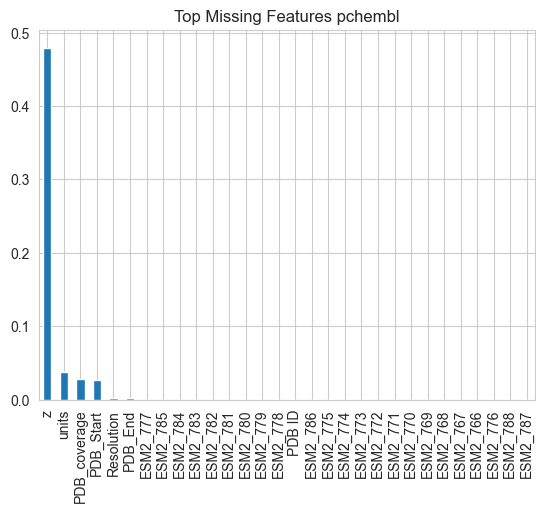

In [6]:
missing = df_pchembl.isnull().mean().sort_values(ascending=False)

plt.figure()
missing.head(30).plot(kind='bar')
plt.title("Top Missing Features pchembl")
plt.show()

### **pki**

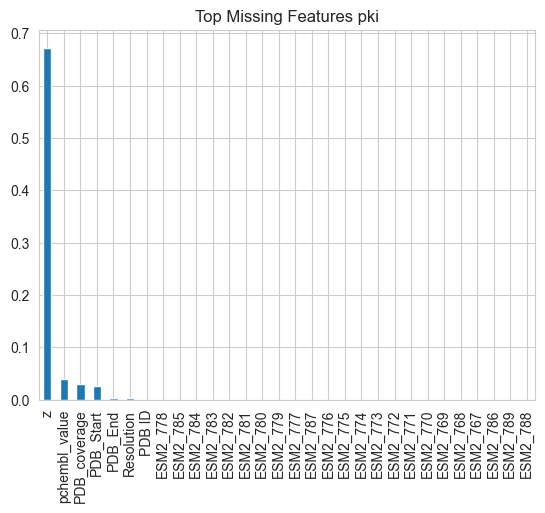

In [7]:
missing = df_pki.isnull().mean().sort_values(ascending=False)

plt.figure()
missing.head(30).plot(kind='bar')
plt.title("Top Missing Features pki")
plt.show()

## **Traget Variable Analysis**

### **pchembl**

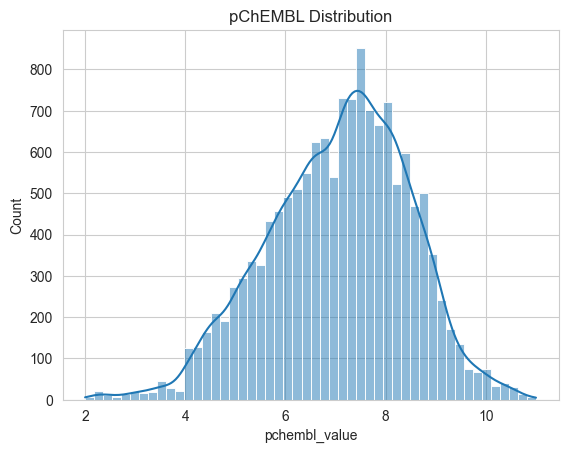

Outliers: 84


In [8]:
plt.figure()
sns.histplot(df_pchembl['pchembl_value'], bins=50, kde=True)
plt.title("pChEMBL Distribution")
plt.show()

# Outliers
q1, q3 = df_pchembl['pchembl_value'].quantile([0.25, 0.75])
iqr = q3 - q1

outliers = df_pchembl[
    (df_pchembl['pchembl_value'] < q1 - 1.5 * iqr) |
    (df_pchembl['pchembl_value'] > q3 + 1.5 * iqr)
]

print(f"Outliers: {len(outliers)}")

### **pki**

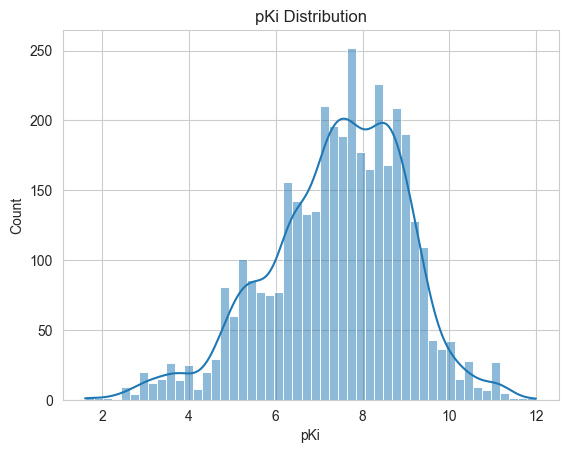

Outliers: 52


In [17]:
plt.figure()
sns.histplot(df_pki['pKi'], bins=50, kde=True)
plt.title("pKi Distribution")
plt.show()

# Outliers
q1, q3 = df_pki['pKi'].quantile([0.25, 0.75])
iqr = q3 - q1

outliers = df_pki[
    (df_pki['pKi'] < q1 - 1.5 * iqr) |
    (df_pki['pKi'] > q3 + 1.5 * iqr)
]

print(f"Outliers: {len(outliers)}")

## **Protein Coverage Analysis**

### **pchembl**

/var/folders/g2/tky8jb016tj7xyjp6djvwrv80000gn/T/ipykernel_20745/895666255.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pchembl['coverage'] = (df_pchembl['PDB_End'] - df_pchembl['PDB_Start']) / (df_pchembl['UniProt_End'] - df_pchembl['UniProt_Start'])


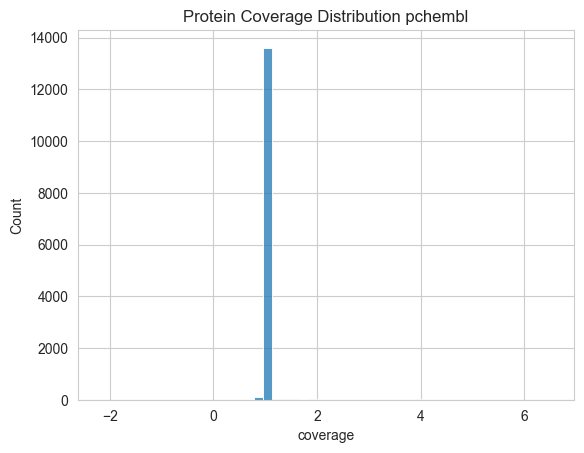

In [9]:
df_pchembl['coverage'] = (df_pchembl['PDB_End'] - df_pchembl['PDB_Start']) / (df_pchembl['UniProt_End'] - df_pchembl['UniProt_Start'])

plt.figure()
sns.histplot(df_pchembl['coverage'], bins=50)
plt.title("Protein Coverage Distribution pchembl")
plt.show()

### **pki**

/var/folders/g2/tky8jb016tj7xyjp6djvwrv80000gn/T/ipykernel_20745/1406574866.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pki['coverage'] = (df_pki['PDB_End'] - df_pki['PDB_Start']) / (df_pki['UniProt_End'] - df_pki['UniProt_Start'])


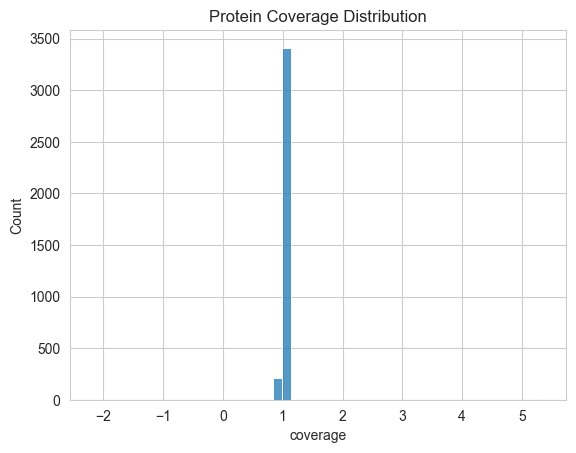

In [10]:
df_pki['coverage'] = (df_pki['PDB_End'] - df_pki['PDB_Start']) / (df_pki['UniProt_End'] - df_pki['UniProt_Start'])

plt.figure()
sns.histplot(df_pki['coverage'], bins=50)
plt.title("Protein Coverage Distribution")
plt.show()

## **Ligand Chemical Space**

### **pchembl**

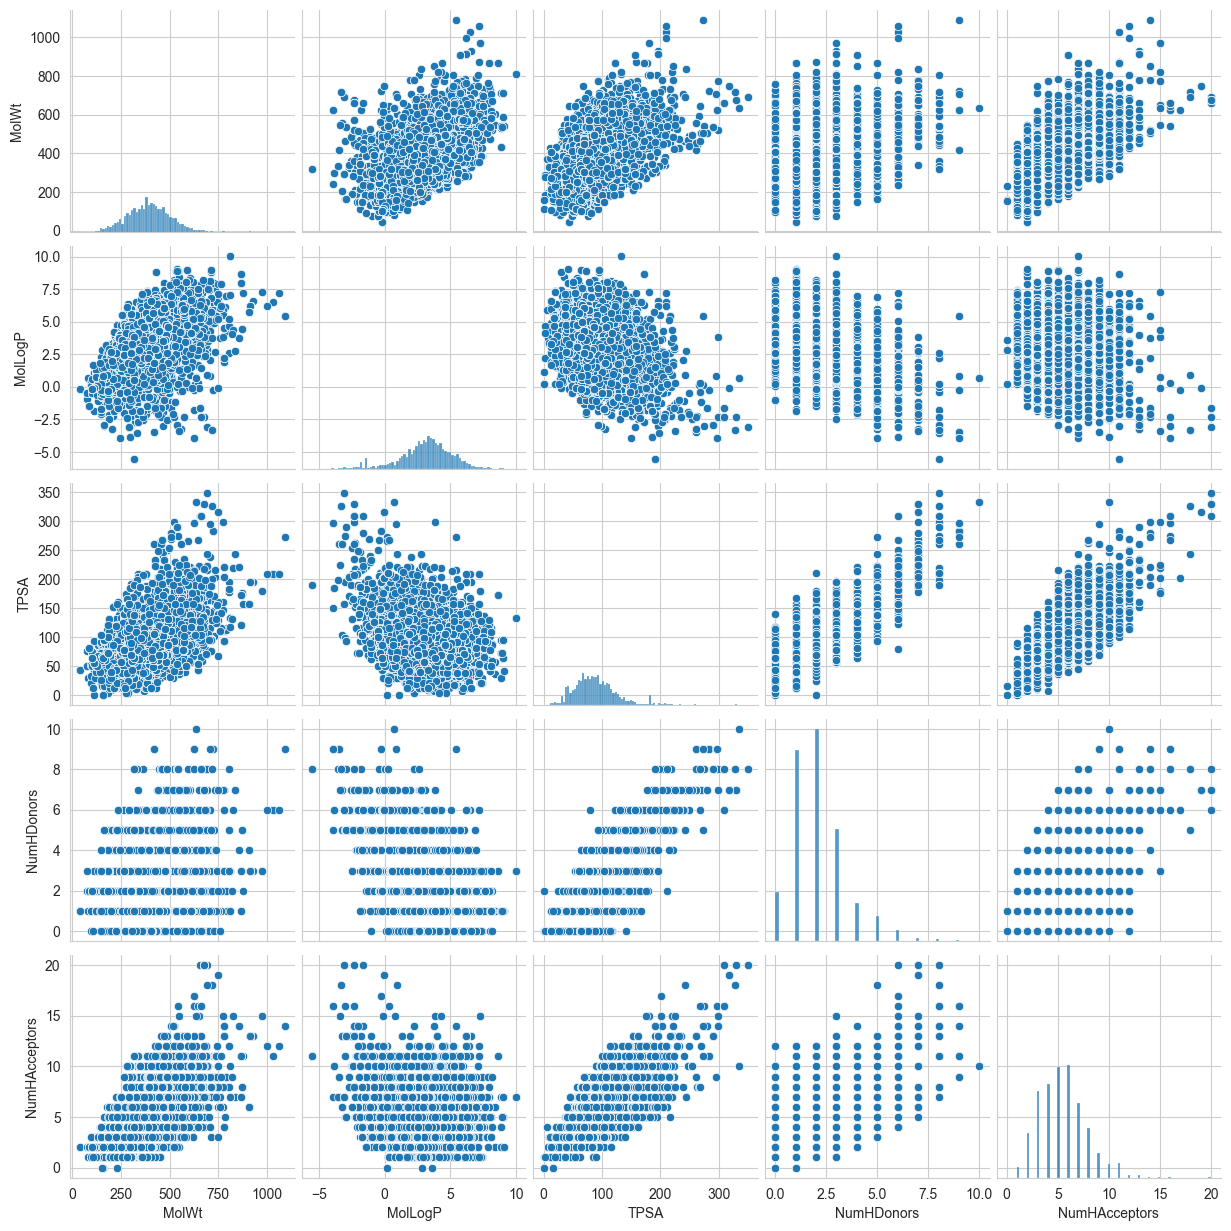

In [11]:
features = ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors']

sns.pairplot(df_pchembl[features].dropna())
plt.show()

### **pki**

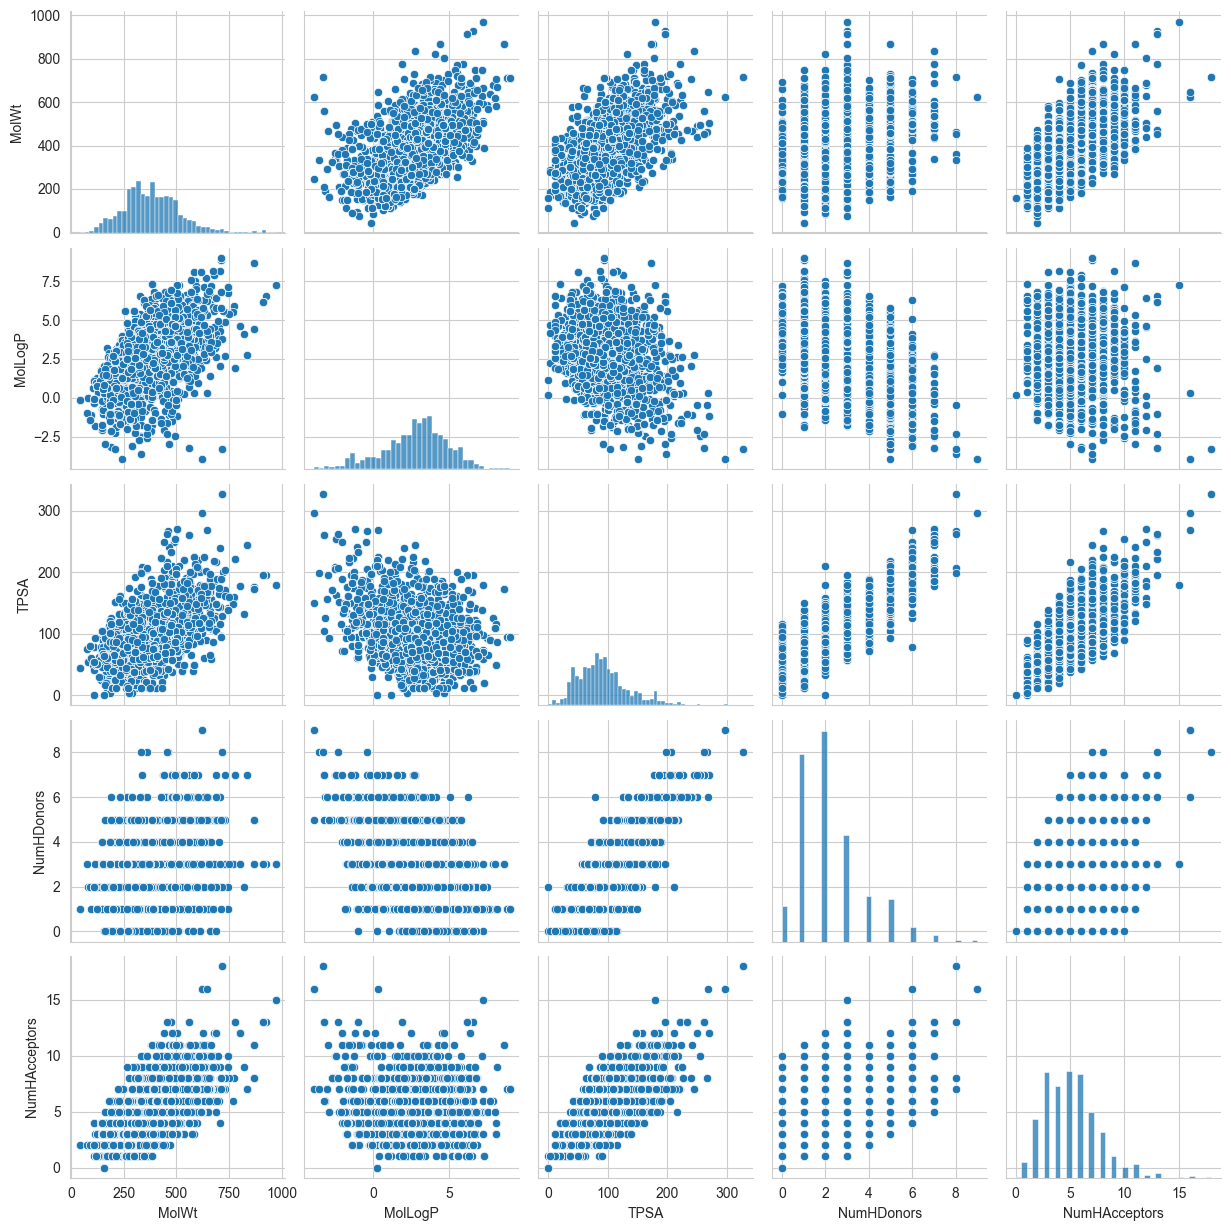

In [12]:
features = ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors']

sns.pairplot(df_pki[features].dropna())
plt.show()

## **Correlation Analysis**

### **pchembl**

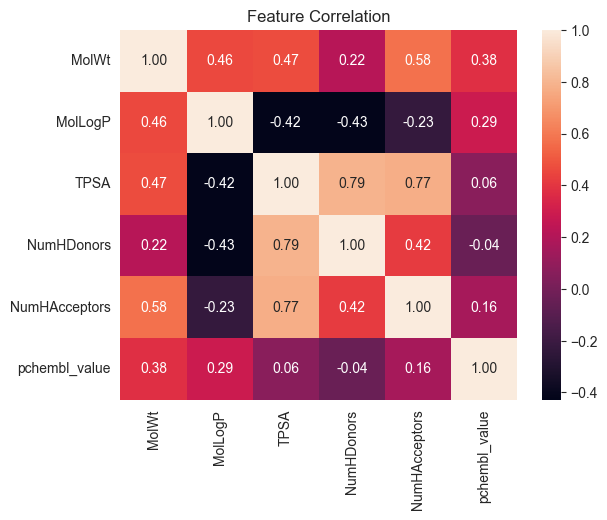

In [13]:
corr = df_pchembl[features + ['pchembl_value']].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Feature Correlation")
plt.show()

### **pki**

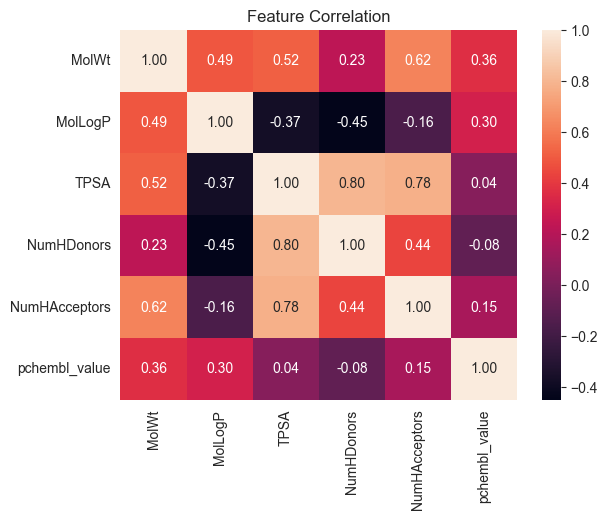

In [14]:
corr = df_pki[features + ['pchembl_value']].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Feature Correlation")
plt.show()

## **ESM Embeddings Analysis**

### **pchembl**

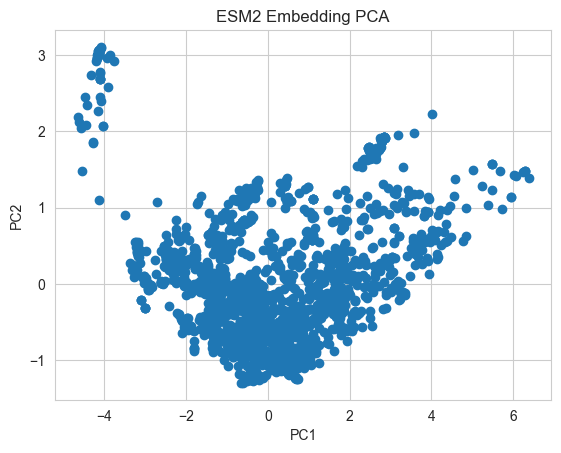

In [16]:
sample_esm = df_pchembl[esm_cols].dropna().sample(2000, random_state=42)

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(sample_esm)

plt.figure()
plt.scatter(emb_2d[:, 0], emb_2d[:, 1])
plt.title("ESM2 Embedding PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### **pki**

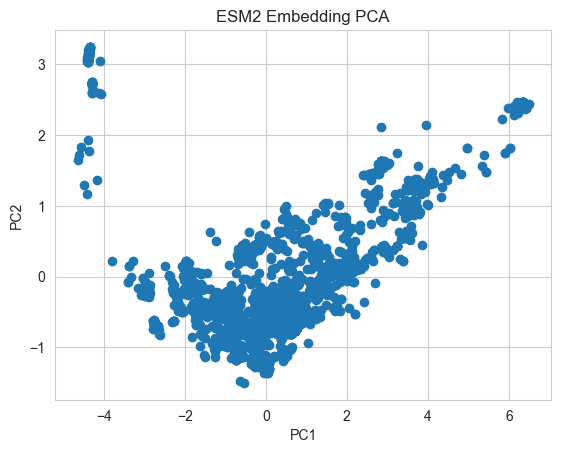

In [17]:
sample_esm = df_pki[esm_cols].dropna().sample(2000, random_state=42)

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(sample_esm)

plt.figure()
plt.scatter(emb_2d[:, 0], emb_2d[:, 1])
plt.title("ESM2 Embedding PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# **Conclusion**

This exploratory analysis characterised the structure and quality of both the pChEMBL and pKi datasets across six key dimensions.

- **Dataset Size and Dimensionality** pChEMBL contains 14,215 entries across 1,511 columns, while pKi is considerably smaller with 3,744 entries and 1,508 columns. Both datasets are high-dimensional by nature: the dominant feature group in both cases is the ESM2 protein embedding, which contributes 1,280 dimensions per entry, complemented by 6 physicochemical ligand descriptors (MolWt, MolLogP, TPSA, NumHDonors, NumHAcceptors, NumRotatableBonds) and a set of structural and identifier columns. The high dimensionality relative to the number of samples — particularly in pKi — is a relevant consideration for model regularisation and feature selection.

- **Missing Values** Both datasets present missing values concentrated in the structural columns (PDB_Start, PDB_End) and, to a lesser extent, in the physicochemical ligand features, as shown in the top-30 missing feature plots. The ESM2 embeddings are largely complete. Missing structural metadata (e.g. chain resolution, PDB coordinates) may reflect incomplete PDB annotations rather than data collection errors, and their impact on modelling should be assessed during feature selection.

- **Target Variable Distribution** The pChEMBL distribution is approximately bell-shaped and centred around values typical of drug-like compounds, with 84 outliers identified via IQR. The pKi distribution follows a similar unimodal shape with 52 outliers. The moderate number of outliers in both cases suggests that the datasets are reasonably well-curated, though these extreme values — which may reflect genuinely very potent or very inactive compounds, or experimental artefacts — warrant inspection before training to decide whether to retain, clip, or exclude them.

- **Protein Coverage** The coverage metric, defined as the ratio of the PDB-resolved region to the full UniProt sequence length, reveals that many structures capture only a partial fragment of the protein rather than the full sequence. This is expected for large multi-domain proteins, where crystallography typically resolves the binding domain of interest. However, it implies that the ESM2 embeddings — which are computed from the full sequence — may encode information beyond what is structurally resolved in the PDB entry, introducing a potential mismatch between the structural context of the binding event and the protein representation fed to the model.

- **Ligand Chemical Space** The pairplot of physicochemical features (MolWt, MolLogP, TPSA, NumHDonors, NumHAcceptors) shows that the ligand space in both datasets is broadly consistent with drug-like chemical space, though with visible clustering that reflects the dominance of specific target families and scaffold families identified in the leakage analysis. The correlation heatmap reveals that the physicochemical features are largely uncorrelated with pChEMBL and pKi values when considered individually, suggesting that binding affinity is not well-captured by global molecular properties alone and that richer structural representations — such as fingerprints or graph-based encodings — will likely be necessary.

- **ESM2 Embedding Structure** The PCA projection of the ESM2 embeddings onto two principal components reveals that the protein space is not uniformly distributed: visible clustering is present in both datasets, reflecting the grouping of proteins into structural and functional families. This is consistent with the high embedding similarity reported in the leakage analysis. The existence of these clusters has direct implications for splitting strategy — a random split would frequently place proteins from the same cluster in both train and test — and suggests that the ESM2 embeddings carry meaningful biological structure that a model should be able to exploit.

Overall, both datasets are well-suited for regression modelling of binding affinity but require careful preprocessing: deduplication, missing value handling, and a principled splitting strategy. The high dimensionality of the ESM2 features relative to dataset size, the partial protein coverage from PDB structures, and the weak univariate correlation between physicochemical features and the target all point toward the need for models capable of learning complex, high-dimensional representations — such as gradient boosting over concatenated feature spaces or neural architectures that handle protein and ligand embeddings jointly.